In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
feature_path = "../data/features/nifty_50_features.csv"

df_features = pd.read_csv(
    feature_path,
    index_col=0,
    parse_dates=True
)

df_features.head()


,Open,High,Low,Close,Volume,daily_return,log_return,vol_20d
Date,,,,,,,,
2015-02-02,8802.500000,8840.799805,8751.099609,8797.400391,210100,-0.001305,-0.001306,0.185397
2015-02-03,8823.150391,8837.299805,8726.650391,8756.549805,208700,-0.004643,-0.004654,0.186447
2015-02-04,8789.150391,8792.849609,8704.400391,8723.700195,195300,-0.003751,-0.003758,0.143674
2015-02-05,8733.099609,8838.450195,8683.650391,8711.700195,173600,-0.001376,-0.001377,0.142737
2015-02-06,8696.849609,8726.200195,8645.549805,8661.049805,171300,-0.005814,-0.005831,0.138326


In [3]:
vol_threshold = df_features["vol_20d"].median()

df_features["vol_regime"] = np.where(
    df_features["vol_20d"] <= vol_threshold,
    "Low Volatility",
    "High Volatility"
)

df_features[["vol_20d", "vol_regime"]].head()


,vol_20d,vol_regime
Date,,
2015-02-02,0.185397,High Volatility
2015-02-03,0.186447,High Volatility
2015-02-04,0.143674,High Volatility
2015-02-05,0.142737,High Volatility
2015-02-06,0.138326,High Volatility


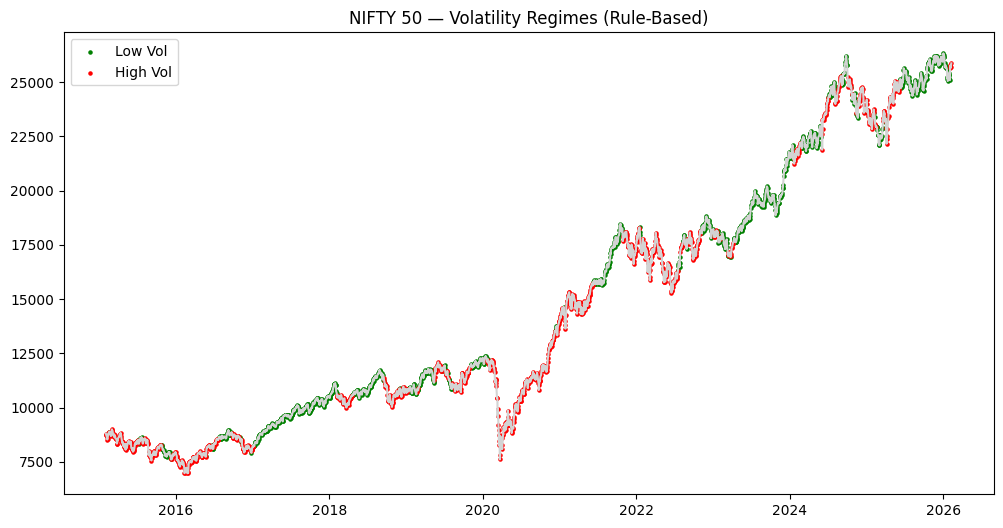

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

low_vol = df_features[df_features["vol_regime"] == "Low Volatility"]
high_vol = df_features[df_features["vol_regime"] == "High Volatility"]

plt.plot(df_features.index, df_features["Close"], color="lightgray")

plt.scatter(low_vol.index, low_vol["Close"], s=5, color="green", label="Low Vol")
plt.scatter(high_vol.index, high_vol["Close"], s=5, color="red", label="High Vol")

plt.legend()
plt.title("NIFTY 50 — Volatility Regimes (Rule-Based)")
plt.show()


In [5]:
cluster_features = [
    "log_return",
    "vol_20d"
]

X = df_features[cluster_features].dropna().copy()
X.head()


,log_return,vol_20d
Date,,
2015-02-02,-0.001306,0.185397
2015-02-03,-0.004654,0.186447
2015-02-04,-0.003758,0.143674
2015-02-05,-0.001377,0.142737
2015-02-06,-0.005831,0.138326


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


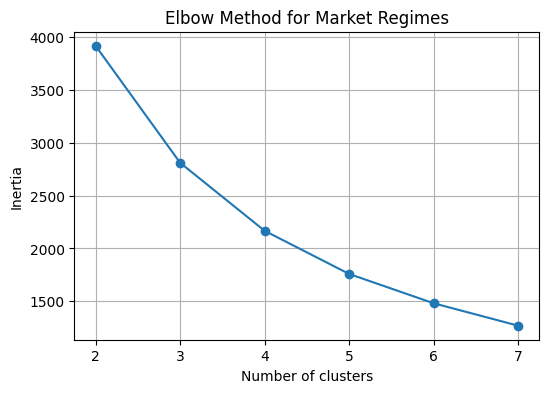

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(2, 8), inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Market Regimes")
plt.grid(True)
plt.show()


In [9]:
df_features["vol_z"] = (
    df_features["vol_20d"] - df_features["vol_20d"].mean()
) / df_features["vol_20d"].std()

df_features["vol_z"].describe()


count    2.714000e+03
mean     1.780284e-16
std      1.000000e+00
min     -1.094743e+00
25%     -5.409866e-01
50%     -2.244924e-01
75%      2.112530e-01
max      9.277537e+00
Name: vol_z, dtype: float64

In [10]:
df_cluster = df_features[df_features["vol_z"].abs() <= 3].copy()

print("Original rows:", len(df_features))
print("After outlier removal:", len(df_cluster))


Original rows: 2714
After outlier removal: 2679


In [11]:
cluster_features = ["log_return", "vol_20d"]

X = df_cluster[cluster_features].copy()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

df_cluster["cluster_regime"] = kmeans.fit_predict(X_scaled)

df_cluster["cluster_regime"].value_counts()


cluster_regime
0    2044
1     635
Name: count, dtype: int64

In [13]:
df_features["cluster_regime"] = np.nan
df_features.loc[df_cluster.index, "cluster_regime"] = df_cluster["cluster_regime"]


In [14]:
regime_runs = (
    df_features["cluster_regime"]
    .ne(df_features["cluster_regime"].shift())
    .cumsum()
)

regime_duration = (
    df_features
    .groupby(regime_runs)["cluster_regime"]
    .count()
)

regime_duration.describe()


count    252.000000
mean      10.630952
std       34.085005
min        0.000000
25%        1.000000
50%        2.000000
75%        4.250000
max      325.000000
Name: cluster_regime, dtype: float64

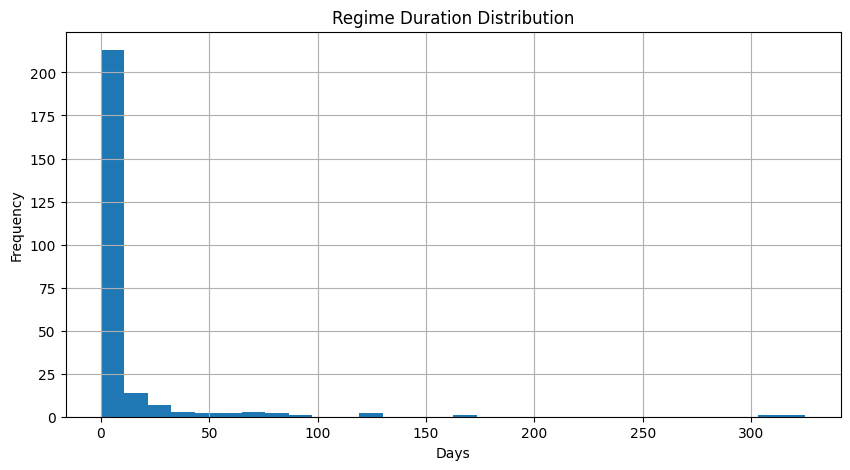

In [15]:
plt.figure(figsize=(10,5))
regime_duration.hist(bins=30)
plt.title("Regime Duration Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()


In [16]:
regime_series = df_features["cluster_regime"].dropna()

transition = pd.crosstab(
    regime_series.shift(1),
    regime_series,
    normalize="index"
)

transition


cluster_regime,0.0,1.0
cluster_regime,,
0.0,0.947626,0.052374
1.0,0.170079,0.829921


In [17]:
df_features["cluster_regime"].value_counts(dropna=False)


cluster_regime
0.0    2044
1.0     635
NaN      35
Name: count, dtype: int64

In [19]:
regime_summary = (
    df_features
    .groupby("cluster_regime")
    .agg(
        avg_return=("log_return", "mean"),
        volatility=("log_return", "std"),
        avg_volume=("Volume", "mean"),
        count=("log_return", "count")
    )
)

regime_summary


,avg_return,volatility,avg_volume,count
cluster_regime,,,,
0.0,-0.000492,0.007364,292442.808219,2044
1.0,0.003345,0.012815,396065.354331,635


In [20]:
regime_map = {
    0.0: "Low-Vol Sideways",
    1.0: "High-Vol Bull"
}

df_features["regime_name"] = df_features["cluster_regime"].map(regime_map)

df_features[["cluster_regime", "regime_name"]].value_counts()


cluster_regime  regime_name     
0.0             Low-Vol Sideways    2044
1.0             High-Vol Bull        635
Name: count, dtype: int64

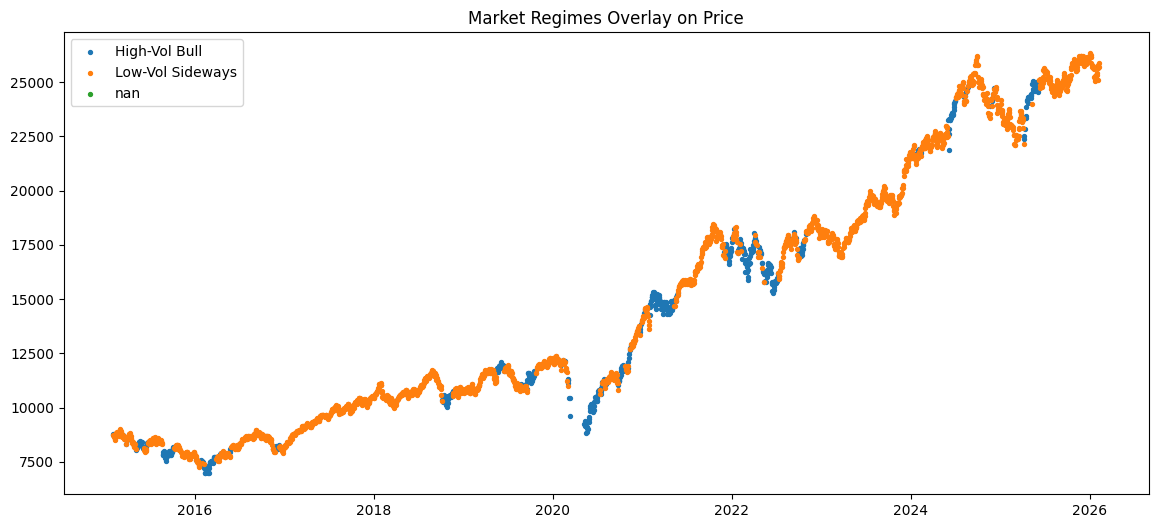

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

for name in df_features["regime_name"].unique():
    subset = df_features[df_features["regime_name"] == name]
    plt.scatter(
        subset.index,
        subset["Close"],
        label=name,
        s=8
    )

plt.title("Market Regimes Overlay on Price")
plt.legend()
plt.show()


In [22]:
df_final = df_features.dropna(subset=["regime_name"]).copy()


In [23]:
final_path = "../data/processed/nifty_50_regime_labeled.csv"
df_final.to_csv(final_path)

final_path


'../data/processed/nifty_50_regime_labeled.csv'